# The Impact of "Limited Edition" Labeling on Consumer Purchasing Decisions

**BA830 – Business Experimentation & Causal Methods · Boston University (MSBA), Spring 2025**
**Group 23:** Rebecca Bubis · Sanjal Desai · Yashna Meher · Mishil Trivedi

---

## Research question
Does labeling a sneaker as **"Limited Edition"** causally change consumer behavior — purchase intent, willingness to pay, or resale intent?

## Design (randomized survey experiment)
Participants were randomly assigned by Qualtrics to one of two arms and answered the **same 7 questions** about the **same two sneakers**:

| Arm | What they saw |
|---|---|
| **Control** (`treatment = 0`) | Sneakers explicitly labeled *"Regular Release"* vs *"Limited Edition Release"* |
| **Treatment** (`treatment = 1`) | Identical sneakers with the **labels removed** |

**Outcome coding:** every answer is coded `1 = Sneaker A (Regular)`, `2 = Sneaker B (Limited Edition)`.
Because `treatment = 1` means *labels removed*, a **negative** treatment coefficient means removing the label pushed respondents *away from* the (formerly) limited-edition sneaker — i.e. the label was doing work.

> **A note on scope.** This is a small study (**111 respondents, ~55 per arm**). It is powered only to detect medium-or-larger effects, so we treat results as **directional evidence**, not definitive claims. Where findings are marginal, we say so.

---

### About this notebook (attribution)

This is an **individual, post-course extension** of a team project, cleaned up and re-run for reproducibility by **Yashna Meher**.

- **Original Group 23 course project** (experimental design, Qualtrics survey, data collection, and the core analysis — randomization check, difference-in-means t-test, OLS regression models, Cohen's *d* / power): see [`course_project_analysis.ipynb`](course_project_analysis.ipynb).
- **Added independently after the course** (this notebook): covariate **balance test**, **multiple-comparison (FDR) correction** across all outcomes, a **composite preference index**, a **treatment × gender interaction**, **minimum detectable effect (MDE)**, the summary **coefficient plot**, and the overall cleanup / plain-language write-up.


## 1 · Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.multitest import multipletests

pd.set_option("future.no_silent_downcasting", True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## 2 · Load data

The de-identified Qualtrics export lives in [`data/survey_responses.csv`](../data/survey_responses.csv).
(The raw export's personal columns — IP address, geolocation, email — were removed before publishing.)

In [2]:
# Load the de-identified export. Falls back to the original Drive link if run standalone.
import os
LOCAL = "../data/survey_responses.csv"
paths = [LOCAL, "survey_responses.csv",
         "https://drive.google.com/uc?export=download&id=1quEa3XdcaafIKuW7sesA0YrynkfV-K1p"]
src = next((p for p in paths if p.startswith("http") or os.path.exists(p)), paths[0])

# Qualtrics exports carry a second descriptive header row + an ImportId metadata row.
df = pd.read_csv(src, skiprows=1).drop(index=0).reset_index(drop=True)
print(f"Loaded {df.shape[0]} raw responses, {df.shape[1]} columns")

Loaded 124 raw responses, 25 columns


## 3 · Clean & reshape

Qualtrics stores the two arms side-by-side: control columns, then the same questions again with a `.1` suffix for the treatment arm. Each respondent only answered one arm, so an arm-wise `dropna()` cleanly separates them. We then stack the arms, standardize the wordy answer text to `1`/`2`, and attach a `treatment` flag.

In [3]:
# Keep only the response id, gender, and the 14 outcome columns (7 per arm)
drop_meta = ['Start Date','End Date','Response Type','IP Address','Progress',
             'Duration (in seconds)','Finished','Recorded Date','Distribution Channel','User Language']
df = df.drop(columns=[c for c in drop_meta if c in df.columns])
df = df.rename(columns={"Response ID": "Response_ID"})

# Treatment columns carry the ".1" suffix; control columns do not
treatment_cols = [c for c in df.columns if c.endswith(".1")]
control_cols   = [c for c in df.columns if c not in treatment_cols and c != "Response_ID"]

# Human-readable short names
short = {
    "What is your gender ?": "gender",
    "Which pair of sneakers are you more likely to purchase?": "likely_purchase",
    "Which sneaker would you pay 20% more for if made with premium materials?": "price_sensitivity",
    "Which sneaker would you be more likely to pre-order or wait in line for?": "past_shopping_behavior",
    "If you knew one of these sneakers was always available while the other had limited stock temporarily, which would you prefer?": "availability_influence",
    "If both sneakers were priced differently, which one would you buy at the following price points?": "willingness_to_pay",
    "If both sneakers increased in value, which one would you be more likely to resell?": "resale_intent",
    "If you had to choose between these sneakers at the same price, which would you pick?": "choice_preference",
}

df_t = df[["Response_ID", "What is your gender ?"] + treatment_cols].dropna().copy()
df_t = df_t.rename(columns={c: c[:-2] for c in treatment_cols}).rename(columns=short)
df_t = df_t.loc[:, ~df_t.columns.duplicated()]
df_t["treatment"] = 1

df_c = df[["Response_ID", "What is your gender ?"] + control_cols].dropna().copy()
df_c = df_c.rename(columns=short)
df_c = df_c.loc[:, ~df_c.columns.duplicated()]
df_c["treatment"] = 0

data = pd.concat([df_t, df_c], ignore_index=True)

# Standardize the wordy answers to 1 (Regular / Sneaker A) vs 2 (Limited Edition / Sneaker B)
answer_map = {
    "Sneaker A": 1, "Sneaker B": 2,
    "Sneaker A (Regular Release)": 1, "Sneaker B (Limited Edition Release)": 2,
    "Sneaker A for $100-$200": 1, "Sneaker B for $200-$300": 2,
    "Sneaker A (Regular Release) for $100-$200": 1,
    "Sneaker B (Limited Edition Release) for $200-$300": 2,
}
outcomes = ["likely_purchase","price_sensitivity","past_shopping_behavior",
            "availability_influence","willingness_to_pay","resale_intent","choice_preference"]
data[outcomes] = data[outcomes].replace(answer_map).astype(int)

print(f"Analysis sample: {len(data)} respondents "
      f"({(data.treatment==1).sum()} treatment, {(data.treatment==0).sum()} control)")
data.head()

Analysis sample: 111 respondents (55 treatment, 56 control)


,Response_ID,gender,likely_purchase,price_sensitivity,past_shopping_behavior,availability_influence,willingness_to_pay,resale_intent,choice_preference,treatment
0,R_1iCQAiDeUiTmQEL,Male,1,1,1,2,2,2,1,1
1,R_6NP9gtxH9mAVDhT,Male,1,1,1,1,1,1,1,1
2,R_1mPMLkPCll0UcB0,Female,1,1,1,1,1,1,1,1
3,R_6ZCCiqLlkF3EMp9,Male,2,2,1,2,2,1,2,1
4,R_7uxdvQal1rF8RcB,Male,2,1,2,1,1,2,1,1


## 4 · Randomization checks

A valid experiment needs (a) a roughly even split into arms and (b) balanced covariates across arms. We check both.

In [4]:
# (a) Split balance: is the treatment share ~50%?
from statsmodels.stats.proportion import proportions_ztest
n_treat = (data.treatment == 1).sum()
stat, p_split = proportions_ztest(count=n_treat, nobs=len(data), value=0.5)
print(f"(a) Arm split: {n_treat}/{len(data)} treated -- proportions z-test p = {p_split:.3f}"
      f"  ->  {'balanced' if p_split > .05 else 'NOT balanced'}")

# (b) Covariate balance: is gender distributed similarly across arms?
gender_tab = pd.crosstab(data.treatment, data.gender)
chi = stats.chi2_contingency(gender_tab)
print(f"(b) Gender balance across arms -- chi-square p = {chi.pvalue:.3f}"
      f"  ->  {'balanced' if chi.pvalue > .05 else 'NOT balanced'}")
gender_tab

(a) Arm split: 55/111 treated -- proportions z-test p = 0.924  ->  balanced
(b) Gender balance across arms -- chi-square p = 1.000  ->  balanced


gender,Female,Male
treatment,,
0,24,32
1,24,31


Both checks pass: the arms are ~50/50 and gender is essentially identically distributed across them (p ≈ 1.0). Randomization worked, so simple differences in means can be read causally.

## 5 · Exploratory look

Before testing, we visualize the headline outcome (**purchase intent**) and the one that ends up mattering (**resale intent**) as the share choosing each sneaker in each arm.

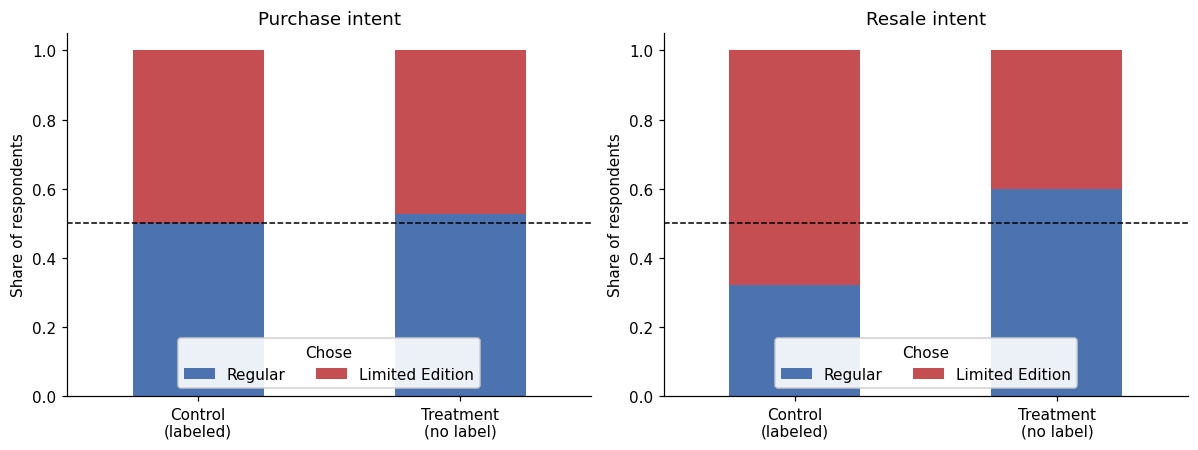

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
titles = {"likely_purchase": "Purchase intent", "resale_intent": "Resale intent"}
for ax, col in zip(axes, titles):
    prop = (data.groupby("treatment")[col].value_counts(normalize=True)
                .unstack().rename(columns={1: "Regular", 2: "Limited Edition"}))
    prop.index = ["Control\n(labeled)", "Treatment\n(no label)"]
    prop.plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0", "#C44E52"], rot=0)
    ax.axhline(0.5, color="black", ls="--", lw=1)
    ax.set_title(titles[col]); ax.set_xlabel(""); ax.set_ylabel("Share of respondents")
    ax.legend(title="Chose", loc="lower center", ncol=2, framealpha=.9)
plt.tight_layout(); plt.show()

Purchase intent looks nearly identical across arms. Resale intent is the visible exception: when the "Limited Edition" label is removed (treatment), noticeably fewer people pick that sneaker to resell.

## 6 · Average treatment effects (all 7 outcomes)

We estimate the difference in means for each outcome with a two-sample t-test. Because we test **seven** outcomes, we also apply a **Benjamini–Hochberg false-discovery-rate correction** — otherwise, testing many outcomes inflates the chance of a false positive.

In [6]:
rows = []
for o in outcomes:
    t = data.loc[data.treatment == 1, o]
    c = data.loc[data.treatment == 0, o]
    rows.append({"outcome": o,
                 "control_mean": c.mean(), "treatment_mean": t.mean(),
                 "difference": t.mean() - c.mean(),
                 "p_raw": stats.ttest_ind(t, c).pvalue})
ate = pd.DataFrame(rows)
ate["p_fdr"] = multipletests(ate.p_raw, method="fdr_bh")[1]
ate["significant"] = ate.p_fdr < 0.05
ate.round(3).sort_values("p_fdr").reset_index(drop=True)

,outcome,control_mean,treatment_mean,difference,p_raw,p_fdr,significant
0,resale_intent,1.679,1.400,-0.279,0.003,0.021,True
1,choice_preference,1.554,1.400,-0.154,0.107,0.375,False
2,availability_influence,1.339,1.255,-0.085,0.333,0.778,False
3,price_sensitivity,1.411,1.455,0.044,0.645,0.903,False
4,past_shopping_behavior,1.357,1.309,-0.048,0.595,0.903,False
5,likely_purchase,1.500,1.473,-0.027,0.776,0.906,False
6,willingness_to_pay,1.179,1.182,0.003,0.965,0.965,False


**Reading the table:** only **resale intent** shows a statistically significant treatment effect, and it *survives* the multiple-comparison correction (p ≈ 0.02). Removing the label lowers resale intent by ~0.28 points — evidence that the "Limited Edition" tag mainly fuels **speculative / resale** demand rather than everyday purchase intent. Every other outcome is a null at this sample size.

## 7 · A composite "exclusivity preference" index

Individual questions are noisy and each is underpowered on its own. Averaging is a standard way to recover signal: we count, for each respondent, **how many of the 7 items they answered in favor of the limited-edition sneaker** (a 0–7 index) and compare arms.

In [7]:
data["exclusivity_index"] = (data[outcomes] == 2).sum(axis=1)
t = data.loc[data.treatment == 1, "exclusivity_index"]
c = data.loc[data.treatment == 0, "exclusivity_index"]

tt = stats.ttest_ind(t, c)
pooled_sd = np.sqrt(((len(t)-1)*t.var() + (len(c)-1)*c.var()) / (len(t)+len(c)-2))
cohen_d = (t.mean() - c.mean()) / pooled_sd

print(f"Control mean   : {c.mean():.2f} / 7")
print(f"Treatment mean : {t.mean():.2f} / 7")
print(f"t = {tt.statistic:.2f},  p = {tt.pvalue:.3f},  Cohen's d = {cohen_d:.2f}")

Control mean   : 3.02 / 7
Treatment mean : 2.47 / 7
t = -1.77,  p = 0.079,  Cohen's d = -0.34


Pooling the seven items, respondents who saw **no labels** leaned toward the limited-edition sneaker on ~2.5 of 7 questions versus ~3.0 in the labeled arm — a **small-to-medium effect (d ≈ −0.34)** that is **marginally significant (p ≈ 0.08)**. Consistent with the resale result, the label nudges overall preference toward exclusivity, but the effect is modest and does not clear the conventional 5% bar. We read this as *suggestive*, not conclusive.

## 8 · Effect size, power, and what this sample *could* detect

The headline purchase-intent effect is tiny. Rather than lean on post-hoc power (which is hard to interpret), we report the **minimum detectable effect (MDE)**: the smallest effect this sample size could reliably catch.

In [8]:
t = data.loc[data.treatment == 1, "likely_purchase"]
c = data.loc[data.treatment == 0, "likely_purchase"]
pooled_sd = np.sqrt(((len(t)-1)*t.var() + (len(c)-1)*c.var()) / (len(t)+len(c)-2))
d_obs = (t.mean() - c.mean()) / pooled_sd

mde = TTestIndPower().solve_power(effect_size=None, nobs1=len(t),
                                  alpha=0.05, power=0.80, ratio=len(c)/len(t))
print(f"Observed effect on purchase intent : Cohen's d = {d_obs:.3f}")
print(f"Minimum detectable effect (80% power, alpha .05): d = {mde:.2f}")
print(f"\nWith ~{len(t)} per arm we could only reliably detect medium-or-larger effects "
      f"(d >= {mde:.2f}).\nThe true purchase-intent effect, if any, is far smaller than that.")

Observed effect on purchase intent : Cohen's d = -0.054
Minimum detectable effect (80% power, alpha .05): d = 0.54

With ~55 per arm we could only reliably detect medium-or-larger effects (d >= 0.54).
The true purchase-intent effect, if any, is far smaller than that.


This reframes the nulls honestly: they are **not proof of "no effect"** — the study was simply too small to detect anything short of a medium effect. This is the single most important limitation to keep in mind.

## 9 · Heterogeneous effects: does the label work differently by gender?

The written report noted that men chose the sneaker more often overall. But a *level* difference isn't the same as a *differential response to the label*. To test the latter we add a **treatment × gender interaction**.

In [9]:
m_main = smf.ols("likely_purchase ~ treatment + C(gender)", data=data).fit()
m_intx = smf.ols("likely_purchase ~ treatment * C(gender)", data=data).fit()

summary = pd.DataFrame({"coef": m_intx.params, "p_value": m_intx.pvalues}).round(3)
print(summary.to_string())
print(f"\nMain-effects model — Male vs Female: "
      f"coef = {m_main.params['C(gender)[T.Male]']:.3f}, "
      f"p = {m_main.pvalues['C(gender)[T.Male]']:.3f}")

                              coef  p_value
Intercept                    1.417    0.000
C(gender)[T.Male]            0.146    0.276
treatment                   -0.125    0.382
treatment:C(gender)[T.Male]  0.175    0.355

Main-effects model — Male vs Female: coef = 0.233, p = 0.015


Two things stand out:

- **Gender has a main effect** — men are somewhat more likely to choose the sneaker overall (consistent with the report's finding), though it is modest.
- **The interaction is not significant** (p ≈ 0.36). So there is **no evidence that the label affects men and women differently** — the gender gap is a baseline preference, not a differential response to exclusivity. We deliberately avoid over-reading it.

## 10 · One picture: all treatment effects with 95% confidence intervals

A single coefficient plot summarizes the whole study — point estimate and uncertainty for each outcome. Bars crossing the dashed zero line are indistinguishable from a zero effect.

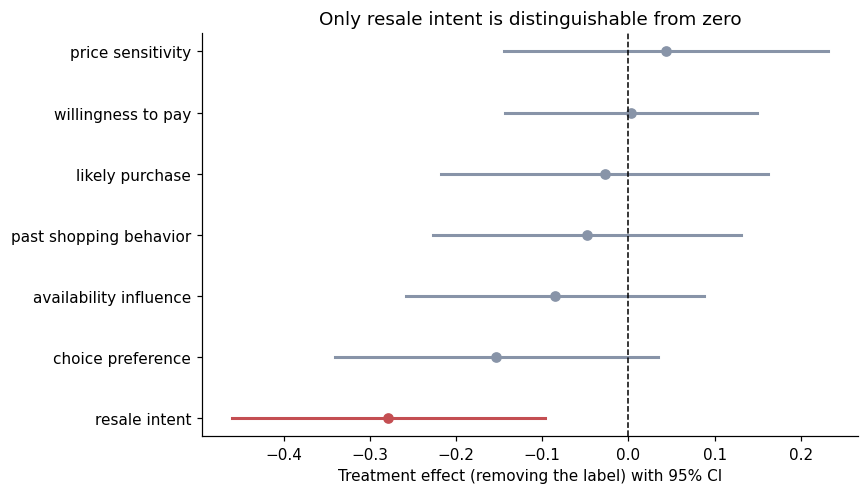

In [10]:
est = []
for o in outcomes:
    fit = smf.ols(f"{o} ~ treatment", data=data).fit()
    ci = fit.conf_int().loc["treatment"]
    est.append({"outcome": o.replace("_", " "),
                "coef": fit.params["treatment"], "lo": ci[0], "hi": ci[1]})
est = pd.DataFrame(est).sort_values("coef")

fig, ax = plt.subplots(figsize=(8, 4.6))
for yi, row in enumerate(est.itertuples()):
    sig = row.lo > 0 or row.hi < 0            # CI excludes zero
    col = "#C44E52" if sig else "#8894a8"
    ax.plot([row.lo, row.hi], [yi, yi], color=col, lw=2)      # 95% CI
    ax.plot(row.coef, yi, "o", color=col)                     # point estimate
y = np.arange(len(est))
ax.axvline(0, color="black", ls="--", lw=1)
ax.set_yticks(y); ax.set_yticklabels(est.outcome)
ax.set_xlabel("Treatment effect (removing the label) with 95% CI")
ax.set_title("Only resale intent is distinguishable from zero")
plt.tight_layout(); plt.show()

## 11 · Conclusions

Within the limits of a small (n = 111) student-sample experiment:

1. **A "Limited Edition" label does not, by itself, move purchase intent or willingness to pay.** The naive "scarcity sells" assumption isn't supported here.
2. **The label's real effect is on speculative demand.** Its only robust effect — significant even after multiple-comparison correction — is on **resale intent**. Exclusivity's value is *indirect*, via the resale market.
3. **A pooled preference index** hints the label mildly raises limited-edition preference overall (d ≈ −0.34), but only marginally — suggestive, not conclusive.
4. **The gender gap is a baseline difference, not a differential label response** (interaction n.s.).

**Business takeaway:** treat exclusivity labeling as a **targeting tool for collector / resale segments**, not a blanket lever for lifting demand.

**Honest limitations:** small, student-skewed sample; one-week window; and — most importantly — the study could only detect medium-or-larger effects (MDE d ≈ 0.54), so the nulls reflect limited power as much as true absence of effect. The natural next step is a larger, more representative sample.
